In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    'StudentID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Math_Score': [88, 92, np.nan, 45, 78, 99, 100, 67, 200, 73],  # 200 is an outlier
    'Science_Score': [91, 85, 89, 76, 73, 95, np.nan, 77, 84, 81],
    'English_Score': [78, 80, 72, 75, 60, 67, 59, 61, 100, 200],  # 200 is outlier
    'Attendance_Percentage': [92, 90, 85, 88, 87, 94, 96, 70, 60, 30]  # 30 is possibly low
}


In [3]:
df = pd.DataFrame(data)
print(df)

   StudentID  Math_Score  Science_Score  English_Score  Attendance_Percentage
0          1        88.0           91.0             78                     92
1          2        92.0           85.0             80                     90
2          3         NaN           89.0             72                     85
3          4        45.0           76.0             75                     88
4          5        78.0           73.0             60                     87
5          6        99.0           95.0             67                     94
6          7       100.0            NaN             59                     96
7          8        67.0           77.0             61                     70
8          9       200.0           84.0            100                     60
9         10        73.0           81.0            200                     30


In [4]:
# Check for missing values
print(df.isnull().sum())

StudentID                0
Math_Score               1
Science_Score            1
English_Score            0
Attendance_Percentage    0
dtype: int64


In [5]:
df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)


In [6]:
print(df)

   StudentID  Math_Score  Science_Score  English_Score  Attendance_Percentage
0          1   88.000000      91.000000             78                     92
1          2   92.000000      85.000000             80                     90
2          3   93.555556      89.000000             72                     85
3          4   45.000000      76.000000             75                     88
4          5   78.000000      73.000000             60                     87
5          6   99.000000      95.000000             67                     94
6          7  100.000000      83.444444             59                     96
7          8   67.000000      77.000000             61                     70
8          9  200.000000      84.000000            100                     60
9         10   73.000000      81.000000            200                     30


In [7]:
# Check outliers using simple rule: value > mean + 2*std or value < mean - 2*std
def remove_outliers_simple(df, column):
    mean = df[column].mean()
    std = df[column].std()
    upper_limit = mean + 2 * std
    lower_limit = mean - 2 * std
    return df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

# Apply this to Math and English scores
df = remove_outliers_simple(df, 'Math_Score')
df = remove_outliers_simple(df, 'English_Score')


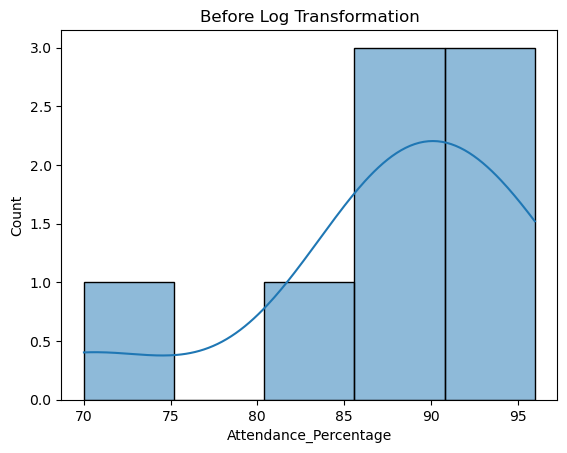

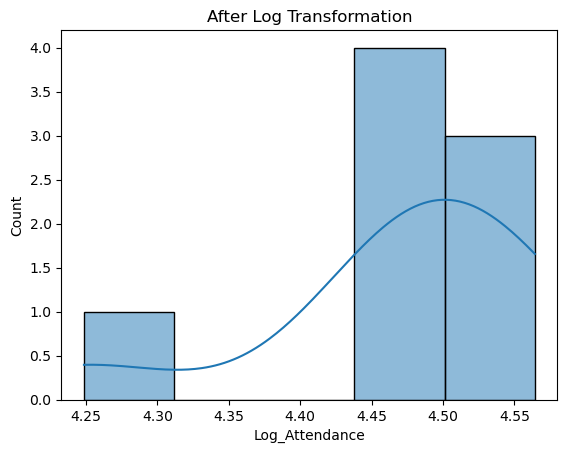

In [9]:

# Before transformation
sns.histplot(df['Attendance_Percentage'], kde=True)
plt.title("Before Log Transformation")
plt.show()

# Apply log transformation
df['Log_Attendance'] = np.log(df['Attendance_Percentage'])

# After transformation
sns.histplot(df['Log_Attendance'], kde=True)
plt.title("After Log Transformation")
plt.show()


   StudentID  Math_Score  Science_Score  English_Score  Attendance_Percentage
0          1        88.0           91.0             78                     92
1          2        92.0           85.0             80                     90
2          3         NaN           89.0             72                     85
3          4        45.0           76.0             75                     88
4          5        78.0           73.0             60                     87
5          6        99.0           95.0             67                     94
6          7       100.0            NaN             59                     96
7          8        67.0           77.0             61                     70
8          9       200.0           84.0            100                     60
9         10        73.0           81.0            200                     30
StudentID                0
Math_Score               1
Science_Score            1
English_Score            0
Attendance_Percentage    0
dtype: 

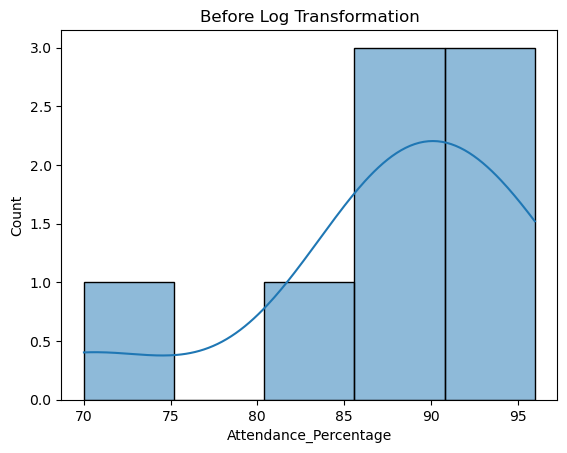

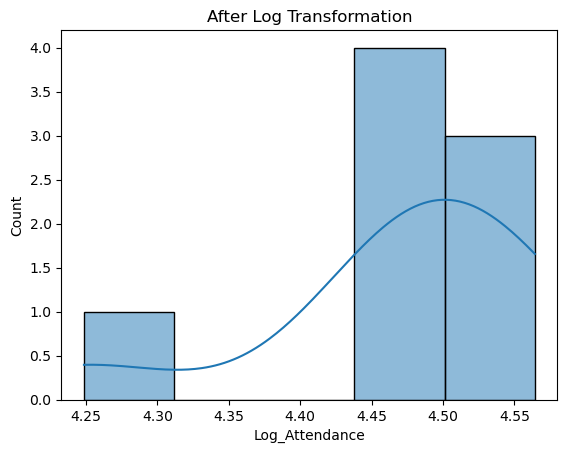

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'StudentID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Math_Score': [88, 92, np.nan, 45, 78, 99, 100, 67, 200, 73],  # 200 is an outlier
    'Science_Score': [91, 85, 89, 76, 73, 95, np.nan, 77, 84, 81],
    'English_Score': [78, 80, 72, 75, 60, 67, 59, 61, 100, 200],  # 200 is outlier
    'Attendance_Percentage': [92, 90, 85, 88, 87, 94, 96, 70, 60, 30]  # 30 is possibly low
}

df = pd.DataFrame(data)
print(df)

# Check for missing values
print(df.isnull().sum())

df['Math_Score'].fillna(df['Math_Score'].mean(), inplace=True)
df['Science_Score'].fillna(df['Science_Score'].mean(), inplace=True)

print(df)

# Check outliers using simple rule: value > mean + 2*std or value < mean - 2*std
def remove_outliers_simple(df, column):
    mean = df[column].mean()
    std = df[column].std()
    upper_limit = mean + 2 * std
    lower_limit = mean - 2 * std
    return df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

# Apply this to Math and English scores
df = remove_outliers_simple(df, 'Math_Score')
df = remove_outliers_simple(df, 'English_Score')


# Before transformation
sns.histplot(df['Attendance_Percentage'], kde=True)
plt.title("Before Log Transformation")
plt.show()

# Apply log transformation
df['Log_Attendance'] = np.log(df['Attendance_Percentage'])

# After transformation
sns.histplot(df['Log_Attendance'], kde=True)
plt.title("After Log Transformation")
plt.show()
